# Processing Time-Series with XEE and XArray

## Introduction

Google Earth Engine (GEE) is a cloud-based platform that has a large public data catalog and computing infrastructure. The [XEE](https://github.com/google/Xee) extension makes it possible to obtain pre-processed data cube directly from GEE as a XArray Dataset. In this section, we will learn how to process the GEE data using XArray and Dask on local compute infrastructure using the time-series processing capabilities of XArray.

## Overview of the Task

We will obtain a datacube of cloud-masked Sentinel-2 images for a year over a chosen region and apply temporal aggregation to obtain mean monthly NDVI images.

*Note: You must have a Google Earth Engine account to complete this section. If you do not have one, [follow our guide](https://courses.spatialthoughts.com/gee-sign-up.html) to sign up.*

**Output**:
* `2019_01.tif`, `2019_02.tif`, ..: 12 GeoTIFF files of monthly mean NDVI calculated from Sentinel-2 L1C scenes.

**Data Credit**:
- Sentinel-2 Level 1C Scenes: Contains modified Copernicus Sentinel data (2025-02)

**Running the Notebook**:
The preferred way to run this notebook is on Google Colab.
<a href='https://colab.research.google.com/github/spatialthoughts/geopython-tutorials/blob/main/notebooks/xee_time_series_processing.ipynb' target='_parent'><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup and Data Download

The following blocks of code will install the required packages and download the datasets to your Colab environment.

In [1]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install xee rioxarray dask['distributed']

In [23]:
import datetime
import ee
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pyproj
import rioxarray as rxr
import xarray
from xee import helpers

In [4]:
output_folder = 'output'

if not os.path.exists(output_folder):
    os.mkdir(output_folder)

## Initialize EE and Dask Cluster

Initialize EE with with the standard endpoint which is recommended to be used with XEE workflows that use server-side computing. Replace the value of the `cloud_project` variable with your own project id that is linked with GEE.


In [5]:
cloud_project = 'spatialthoughts' # replace with your project id

try:
    ee.Initialize(project=cloud_project)
except:
    ee.Authenticate()
    ee.Initialize(project=cloud_project)

Setup a local Dask cluster.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if 'google.colab' in str(get_ipython()):
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))


Each of our Dask workers need Earth Engine authentication. Initialize Dask workers using `ee.Initialize()`.

In [ ]:
from dask.distributed import WorkerPlugin

class EEPlugin(WorkerPlugin):
    def __init__(self):
        pass
    def setup(self, worker):
        self.worker = worker
        try:
            ee.Initialize(
                project=cloud_project,
                opt_url='https://earthengine-highvolume.googleapis.com')
        except:
            ee.Authenticate()
            ee.Initialize(
                project=cloud_project,
                opt_url='https://earthengine-highvolume.googleapis.com')

ee_plugin = EEPlugin()
client.register_plugin(ee_plugin)


## Data Pre-Processing

We start with the Sentinel-2 collection, apply a cloud mask and compute NDVI using the Google Earth Engine API.

In [9]:
s2 = ee.ImageCollection('COPERNICUS/S2_HARMONIZED')
geometry = ee.Geometry.Polygon([[
  [82.60642647743225, 27.16350437805251],
  [82.60984897613525, 27.1618529901377],
  [82.61088967323303, 27.163695288375266],
  [82.60757446289062, 27.16517483230927]
]])

filtered = s2 \
  .filter(ee.Filter.date('2019-01-01', '2020-01-01')) \
  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) \
  .filter(ee.Filter.bounds(geometry))

# Write a function for Cloud masking
def maskS2clouds(image):
  qa = image.select('QA60')
  cloudBitMask = 1 << 10
  cirrusBitMask = 1 << 11
  mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
             qa.bitwiseAnd(cirrusBitMask).eq(0))
  return image.updateMask(mask).multiply(0.0001) \
      .select('B.*') \
      .copyProperties(image, ['system:time_start'])

filtered = filtered.map(maskS2clouds)
# Write a function that computes NDVI for an image and adds it as a band
def addNDVI(image):
  ndvi = image.normalizedDifference(['B8', 'B4']).rename('ndvi')
  return image.addBands(ndvi)

# Map the function over the collection
withNdvi = filtered.map(addNDVI)

We also convert the input ee.Geometry to shapely. This will not be required after [this issue](https://github.com/google/Xee/issues/310) is fixed.

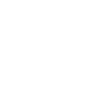

In [11]:
import shapely
input_geometry = shapely.geometry.shape(geometry.getInfo())
input_geometry

XEE requires explicit grid parameters. We extract these using the helper function [`fit_geometry`](https://xee.readthedocs.io/en/latest/_autosummary/xee.fit_geometry.html#xee.fit_geometry).

In [12]:
output_crs = 'EPSG:32644' # UTM Zone 44N
output_scale = 10

grid_params = helpers.fit_geometry(
    geometry=input_geometry,
    geometry_crs='EPSG:4326',  # Input geometry CRS
    grid_crs=output_crs,
    grid_scale=(output_scale, -output_scale)
)
grid_params

{'crs': 'EPSG:32644',
 'crs_transform': (10.0, 0.0, 659160.0, 0.0, -10.0, 3005760.0),
 'shape_2d': (45, 38)}

In [16]:
ds = xarray.open_dataset(
    withNdvi.select('ndvi'),
    engine='ee',
    **grid_params,
    chunks={} # Enable dask
)
ds

<xarray.Dataset> Size: 624kB
Dimensions:  (time: 91, y: 38, x: 45)
Coordinates:
  * time     (time) datetime64[ns] 728B 2019-01-01T05:11:07.231000 ... 2019-1...
  * y        (y) float64 304B 3.006e+06 3.006e+06 ... 3.005e+06 3.005e+06
  * x        (x) float64 360B 6.592e+05 6.592e+05 ... 6.596e+05 6.596e+05
Data variables:
    ndvi     (time, y, x) float32 622kB dask.array<chunksize=(48, 38, 45), meta=np.ndarray>
Attributes: (12/17)
    date_range:             [1435017600000, 1647993600000]
    description:            <p>Sentinel-2 is a wide-swath, high-resolution, m...
    keywords:               ['copernicus', 'esa', 'eu', 'msi', 'radiance', 's...
    period:                 0
    product_tags:           ['msi', 'radiance']
    provider:               European Union/ESA/Copernicus
    ...                     ...
    title:                  Sentinel-2 MSI: MultiSpectral Instrument, Level-1C
    type_name:              ImageCollection
    visualization_0_bands:  B4,B3,B2
    visualization_0_max:    3000.0
    visualization_0_min:    0.0
    visualization_0_name:   RGB

Select the `ndvi` variable. Split the datacube into 'chunks' where all time slices are in a single chunk.

In [18]:
original_time_series = ds.ndvi.chunk({'time': -1})
original_time_series

<xarray.DataArray 'ndvi' (time: 91, y: 38, x: 45)> Size: 622kB
dask.array<rechunk-merge, shape=(91, 38, 45), dtype=float32, chunksize=(91, 38, 45), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 728B 2019-01-01T05:11:07.231000 ... 2019-1...
  * y        (y) float64 304B 3.006e+06 3.006e+06 ... 3.005e+06 3.005e+06
  * x        (x) float64 360B 6.592e+05 6.592e+05 ... 6.596e+05 6.596e+05
Attributes:
    id:             ndvi
    data_type:      {'type': 'PixelType', 'precision': 'float', 'min': -1, 'm...
    dimensions:     [10980, 10980]
    crs:            EPSG:32644
    crs_transform:  [10, 0, 600000, 0, -10, 3100020]

Since the data size is small, we can call `compute()` and load it into memory.

In [19]:
%%time
original_time_series = original_time_series.compute();

CPU times: user 388 ms, sys: 40.2 ms, total: 428 ms
Wall time: 3.75 s


## Aggregating the Time-Series

We have a irregular time-series with a lot of noise. Let's create a monthly NDVI time-series by computing the monthly average NDVI. We can use XArray's `resample()` method to aggregate the time-series by Months and coompute the mean. We specify *time* as `MS` to indicate aggregating by month start and *label* as `left` to indicate we want the start of the month as our series labels.

Reference [Pandas Offset Aliases](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases)

In [ ]:
time_series_aggregated = original_time_series.resample(time='MS', label='left').mean()
time_series_aggregated

Plot and Extract the Time-Series at a Single Location. As our dataset coordinates are in UTM, we convert the lat/lon to UTM coordinates.

In [24]:
latitude = 27.164335
longitude = 82.607376
crs = 'EPSG:32644'
transformer = pyproj.Transformer.from_crs('EPSG:4326', output_crs, always_xy=True)
x, y = transformer.transform(longitude, latitude)
x,y

(659255.906258423, 3005657.109226172)

In [25]:
original_ts = original_time_series.interp(x=x, y=y)
aggregated_ts = time_series_aggregated.interp(x=x, y=y)

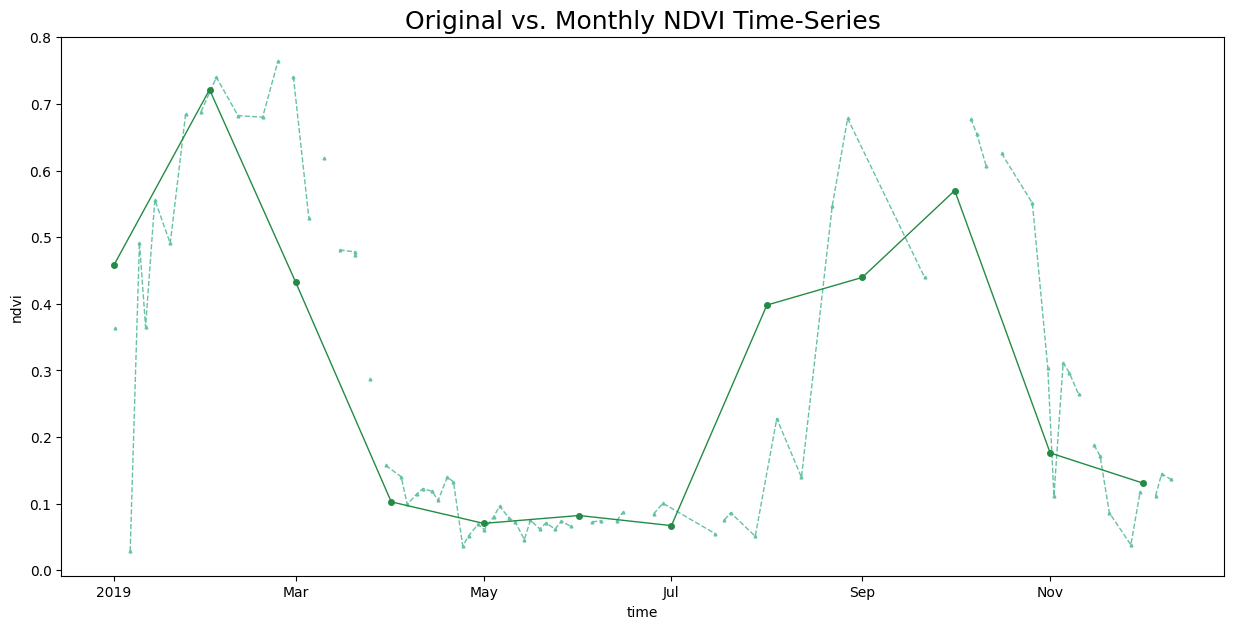

In [26]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 7)
original_ts.plot.line(
    ax=ax, x='time',
    marker='^', color='#66c2a4', linestyle='--', linewidth=1, markersize=2)
aggregated_ts.plot.line(
    ax=ax, x='time',
    marker='o', color='#238b45', linestyle='-', linewidth=1, markersize=4)

ax.set_title('Original vs. Monthly NDVI Time-Series', size = 18)

plt.show()

## Downloading Time-Series Images

Save the processed monthly NDVI images using `rioxarray` as GeoTIFF files.

In [27]:
for time in time_series_aggregated.time.values:
  image = time_series_aggregated.sel(time=time)
  date = np.datetime_as_string(time, unit='M')
  output_file = f'{date}.tif'
  output_path = os.path.join(output_folder, output_file)
  image.rio.to_raster(output_path, driver='COG')
  print(f'Created file at {output_path}')

Created file at output/2019-01.tif
Created file at output/2019-02.tif
Created file at output/2019-03.tif
Created file at output/2019-04.tif
Created file at output/2019-05.tif
Created file at output/2019-06.tif
Created file at output/2019-07.tif
Created file at output/2019-08.tif
Created file at output/2019-09.tif
Created file at output/2019-10.tif
Created file at output/2019-11.tif
Created file at output/2019-12.tif


----

If you want to give feedback or share your experience with this tutorial, please comment below. (requires GitHub account)


<script src='https://utteranc.es/client.js'
    repo='spatialthoughts/geopython-tutorials'
    issue-term='pathname'
    theme='github-light'
    crossorigin='anonymous'
    async>
</script>